In this notebook, we will be creating a CNN (Convolutional Neural Network) based classifier for the classification of CIFAR-10 dataset.

**About the dataset**

CIFAR-10 dataset is a subset of CIFAR-100 having 80 million images of 100 different objects. CIFAR-10 takes 60,000 images for 10 classes from the original dataset in which 50,000 images are for training and 10,000 images are for testing.

The classes in the dataset are -
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

In [16]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


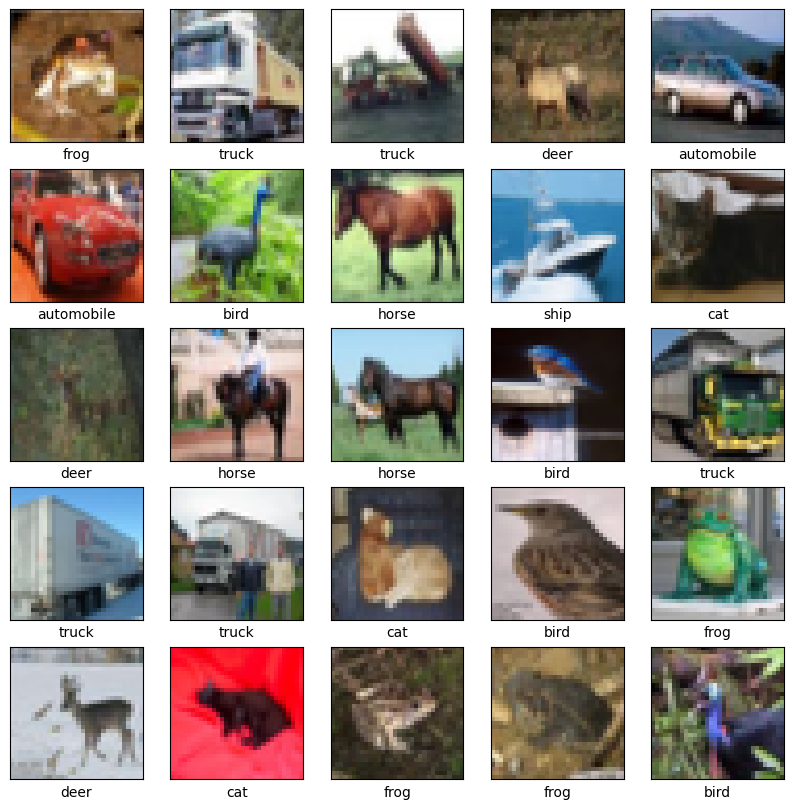

In [17]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Creating a CNN model**

We are going to create a CNN based classification model using *keras* module.

In [18]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='sgd',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))


In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
print(test_acc)

In [20]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))

Epoch 1/10
  44/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.1258 - loss: 2.2948

KeyboardInterrupt: 

In [22]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

NameError: name 'history' is not defined

In [ ]:
print(test_acc)

0.7099000215530396


In [ ]:
# save model
model.save('final_model.keras') #previously saved as 'final_model.h5", a legacy

In [123]:
from google.colab import files
uploaded = files.upload()

Saving Car.jpg to Car.jpg
Saving Horse.jpg to Horse.jpg
Saving Ship.png to Ship.png


In [23]:
from tensorflow.keras import preprocessing
from tensorflow.keras import models
import numpy as np
import matplotlib.pyplot as plt

model = models.load_model('final_model.keras')

In [24]:
def load_image(filename):
    img = preprocessing.image.load_img(filename, target_size=(32, 32))
    img = preprocessing.image.img_to_array(img)
    img = img.reshape(1, 32, 32, 3)
    img = img.astype('float32')
    img = img / 255.0
    return img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Image: Car.jpg
Prediction: automobile


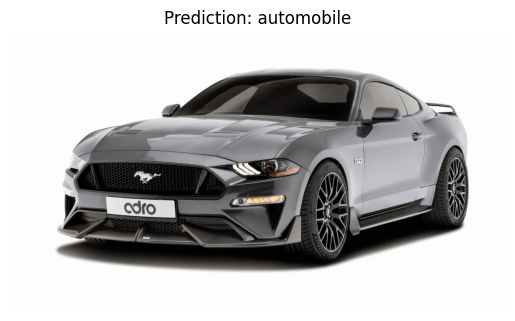

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Image: Horse.jpg
Prediction: horse


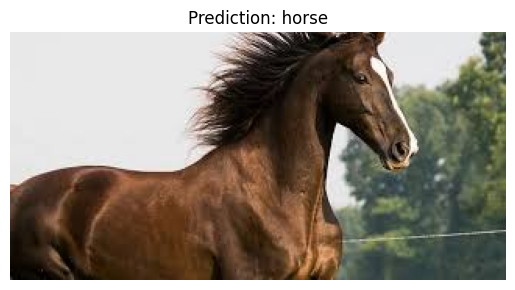

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Image: Ship.png
Prediction: ship


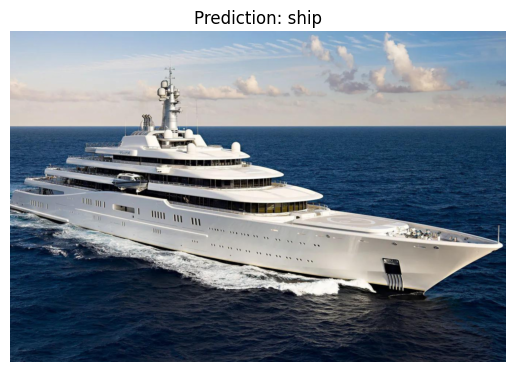

In [124]:
def run_example():

    filenames = ['Car.jpg', 'Horse.jpg', 'Ship.png']

    for filename in filenames:
        img = load_image(filename)

        pred_list = model.predict(img)
        result = np.argmax(pred_list[0])

        print("Image:", filename)
        print("Prediction:", class_names[result])

        plt.imshow(preprocessing.image.load_img(filename))
        plt.title("Prediction: " + class_names[result])
        plt.axis('off')
        plt.show()

run_example()

In [129]:
from google.colab import files
uploaded = files.upload()

Saving webots_horse.png to webots_horse.png


Webots image: webots_horse.png
Prediction: horse
Top 3 predictions:
horse 5.051450252532959
deer 2.848768472671509
dog 2.2392680644989014


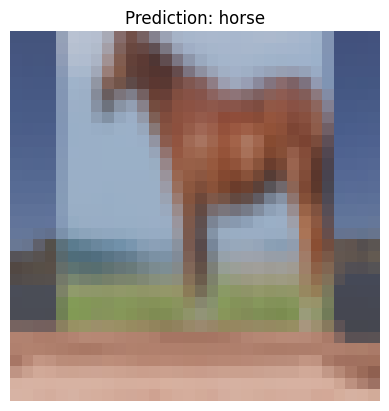

In [130]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def run_webots_example():
    filename = "webots_horse.png"

    # Read image
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Crop (focus on horse)
    h, w, _ = img.shape
    crop = img[int(h*0.02):int(h*0.65), int(w*0.15):int(w*0.85)]

    # Resize + normalize
    crop_resized = cv2.resize(crop, (32, 32))
    crop_input = crop_resized.astype("float32") / 255.0
    crop_input = np.expand_dims(crop_input, axis=0)

    # Predict
    pred_list = model.predict(crop_input, verbose=0)
    result = np.argmax(pred_list[0])

    print("Webots image:", filename)
    print("Prediction:", class_names[result])

    # Top 3 predictions
    top3 = np.argsort(pred_list[0])[-3:][::-1]
    print("Top 3 predictions:")
    for i in top3:
        print(class_names[i], float(pred_list[0][i]))

    # Show image
    plt.imshow(crop_resized)
    plt.title("Prediction: " + class_names[result])
    plt.axis("off")
    plt.show()

run_webots_example()

In [128]:
import os

files = os.listdir()

for f in files:
    if f.endswith('.jpg') or f.endswith('.png'):
        os.remove(f)